Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Preprocessing completed.

===== MODEL COMPARISON =====


,Accuracy,Precision,Recall,F1-score
Unigram TF-IDF,0.8965,0.8865,0.9094,0.8978
Unigram + Bigram TF-IDF,0.9023,0.8928,0.9144,0.9035


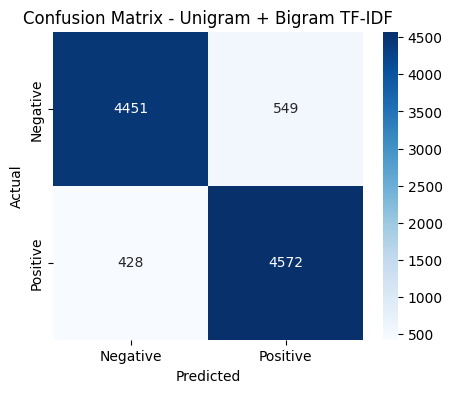


===== BIGRAM COMPARISON =====
Unigram F1: 0.8978
Bigram F1 : 0.9035
Adding bigrams improved sentiment classification.

===== THRESHOLD RESULTS =====


,Threshold,Precision,Recall,F1-score
0,0.3,0.7883,0.9762,0.8722
1,0.5,0.8928,0.9144,0.9035
2,0.7,0.9581,0.7594,0.8473


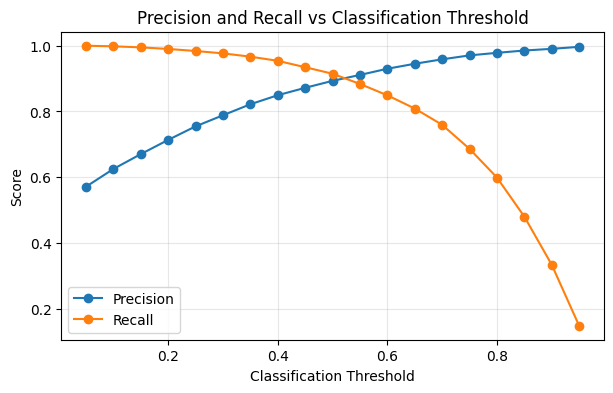


===== 5 BORDERLINE REVIEWS =====


,Review,Actual Sentiment,Predicted Sentiment,Predicted Probability
0,hoped show somewhat realistic stroke another mainstream show watched feel character america glamorized idea terrorism operates main character act like fundamentalist pass terrorist beyond comprehension neither terrorist managed appear genuine one member blonde american white boy would never accepted muslim terrorist real life another member french ex skinhead quite fit islamic terror movement top terrorist sexual relation white american housewife find strange another stupid misguiding americ...,Negative,Negative,0.5000
1,crap hollywood indie churned finally get movie delivers scary moment clich moment sure possible nowadays make entirely original movie much new done well make sure pay attention subtle scare come quickly often movie watch eating pizza one well written red herring movie unfortunately one poorly cast role cheri christian make effective julie wife mother one thing totally unsympathetic know know gone traumatic experience viewer never get know normally relationship husband rather discomforting un...,Positive,Positive,0.5002
2,wonder lot u hate classical music child think educational pr like serious music soon slip life support morgue kid know talked exception someone good movie classical music kid must admit enjoyed actor played beethoven took role enthusiasm keen balance poignant humorous aspect beethoven character obviously research otherwise third rate rehash old abc afterschool special format none occasional charm short film sorry rant important subject young people know could done well wonder musician filmma...,Negative,Positive,0.5003
3,refer malice film noir likening masterpiece sunset boulevard double indemnity maltese falcon comparing director becker alfred hitchcock stanley kubrick stanley kramer luis bunuel merely registering protest darkness pervades movie start finish extent time simply cannot make going understand darkness night scene movie dark even broad daylight reason loss understand however made much difference director becker filmed total darkness,Negative,Negative,0.4997
4,rob estes josie bisset crap load kid look nothing like either basically rob josie shotgun wedding drunken night vega vacation come home find respective child already know nuptials due tabloid like fodder rob josie move eight kid one house rob build furniture think close enough frank lambert patrick duffy construction job much similar step step warrant eternal mockage josie sort cookie making queen though look like make cooky close enough carol foster suzanne somers hairdressing job warrant l...,Positive,Positive,0.5003



===== BORDERLINE CASE ANALYSIS =====

Review 1
Pattern: negation
Actual: Negative
Predicted: Negative
Probability: 0.5
Review: hoped show somewhat realistic stroke another mainstream show watched feel character america glamorized idea terrorism operates main character act like fundamentalist pass terrorist beyond comprehension neither terrorist managed appear genuine one member blonde american white boy would never accepted muslim terrorist real life another member french ex skinhead quite fit islamic terror movement top terrorist sexual relation white american housewife find strange another stupid misguiding american tv show realistic prison break

Review 2
Pattern: negation, positive words
Actual: Positive
Predicted: Positive
Probability: 0.5002
Review: crap hollywood indie churned finally get movie delivers scary moment clich moment sure possible nowadays make entirely original movie much new done well make sure pay attention subtle scare come quickly often movie watch eating pizza

In [1]:
# ===================== QUESTION 1: IMDb SENTIMENT =====================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Download NLTK resources
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# ---------------------------------------------------------
# Load IMDb dataset
# ---------------------------------------------------------
file_path = "/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())

# ---------------------------------------------------------
# Preprocessing
# lowercase -> remove HTML -> tokenize -> stopword removal
# -> lemmatization
# ---------------------------------------------------------
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    words = re.findall(r"[a-z]+", text)
    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words
    ]
    return " ".join(words)

df["preprocessed_text"] = df["review"].apply(preprocess)
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1})

print("\nPreprocessing completed.")

# ---------------------------------------------------------
# (a) Train-test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df["preprocessed_text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

# ---------------------------------------------------------
# (b) TF-IDF: Unigram and Unigram + Bigram
# ---------------------------------------------------------
tfidf_uni = TfidfVectorizer(
    ngram_range=(1,1),
    max_features=50000
)

tfidf_bi = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=50000
)

Xtr_uni = tfidf_uni.fit_transform(X_train)
Xte_uni = tfidf_uni.transform(X_test)

Xtr_bi = tfidf_bi.fit_transform(X_train)
Xte_bi = tfidf_bi.transform(X_test)

# ---------------------------------------------------------
# (c) Logistic Regression
# ---------------------------------------------------------
lr_uni = LogisticRegression(max_iter=1000)
lr_bi = LogisticRegression(max_iter=1000)

lr_uni.fit(Xtr_uni, y_train)
lr_bi.fit(Xtr_bi, y_train)

pred_uni = lr_uni.predict(Xte_uni)
pred_bi = lr_bi.predict(Xte_bi)

# ---------------------------------------------------------
# (d) Accuracy, Precision, Recall, F1
# ---------------------------------------------------------
def get_metrics(y, pred):
    return [
        accuracy_score(y, pred),
        precision_score(y, pred),
        recall_score(y, pred),
        f1_score(y, pred)
    ]

results = pd.DataFrame(
    [
        get_metrics(y_test, pred_uni),
        get_metrics(y_test, pred_bi)
    ],
    columns=["Accuracy", "Precision", "Recall", "F1-score"],
    index=["Unigram TF-IDF", "Unigram + Bigram TF-IDF"]
)

print("\n===== MODEL COMPARISON =====")
display(results.round(4))

# ---------------------------------------------------------
# (e) Confusion matrix for better model
# ---------------------------------------------------------
if results.loc["Unigram + Bigram TF-IDF", "F1-score"] > \
   results.loc["Unigram TF-IDF", "F1-score"]:

    best_name = "Unigram + Bigram TF-IDF"
    best_model = lr_bi
    best_Xtest = Xte_bi
    best_pred = pred_bi

else:
    best_name = "Unigram TF-IDF"
    best_model = lr_uni
    best_Xtest = Xte_uni
    best_pred = pred_uni

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

# ---------------------------------------------------------
# (f) Bigram comparison
# ---------------------------------------------------------
print("\n===== BIGRAM COMPARISON =====")

uni_f1 = results.loc["Unigram TF-IDF", "F1-score"]
bi_f1 = results.loc["Unigram + Bigram TF-IDF", "F1-score"]

print("Unigram F1:", round(uni_f1, 4))
print("Bigram F1 :", round(bi_f1, 4))

if bi_f1 > uni_f1:
    print("Adding bigrams improved sentiment classification.")
else:
    print("Adding bigrams did not improve sentiment classification.")

# ---------------------------------------------------------
# (g) Thresholds 0.3, 0.5, 0.7
# ---------------------------------------------------------
prob = best_model.predict_proba(best_Xtest)[:, 1]

threshold_results = []

for threshold in [0.3, 0.5, 0.7]:

    pred_threshold = (prob >= threshold).astype(int)

    threshold_results.append([
        threshold,
        precision_score(y_test, pred_threshold),
        recall_score(y_test, pred_threshold),
        f1_score(y_test, pred_threshold)
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Precision", "Recall", "F1-score"]
)

print("\n===== THRESHOLD RESULTS =====")
display(threshold_df.round(4))

# ---------------------------------------------------------
# (h) Precision and Recall vs Threshold
# ---------------------------------------------------------
thresholds = np.arange(0.05, 1.00, 0.05)

precisions = []
recalls = []

for threshold in thresholds:

    pred_threshold = (prob >= threshold).astype(int)

    precisions.append(
        precision_score(y_test, pred_threshold, zero_division=0)
    )

    recalls.append(
        recall_score(y_test, pred_threshold, zero_division=0)
    )

plt.figure(figsize=(7,4))

plt.plot(
    thresholds,
    precisions,
    marker="o",
    label="Precision"
)

plt.plot(
    thresholds,
    recalls,
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------------------------------
# (i) Five reviews closest to probability 0.5
# ---------------------------------------------------------
closest = np.argsort(np.abs(prob - 0.5))[:5]

borderline = pd.DataFrame({
    "Review": X_test.iloc[closest].values,
    "Actual Sentiment": [
        "Positive" if y_test.iloc[i] == 1 else "Negative"
        for i in closest
    ],
    "Predicted Sentiment": [
        "Positive" if prob[i] >= 0.5 else "Negative"
        for i in closest
    ],
    "Predicted Probability": np.round(prob[closest], 4)
})

print("\n===== 5 BORDERLINE REVIEWS =====")

pd.set_option("display.max_colwidth", 500)
display(borderline)

# ---------------------------------------------------------
# (j) Linguistic patterns in borderline reviews
# ---------------------------------------------------------
print("\n===== BORDERLINE CASE ANALYSIS =====")

for i, row in borderline.iterrows():

    text = row["Review"].lower()
    patterns = []

    if any(w in text.split()
           for w in ["not", "no", "never", "neither", "nor", "hardly"]):
        patterns.append("negation")

    if any(w in text
           for w in ["but", "however", "although", "though", "despite"]):
        patterns.append("mixed/contrast")

    if any(w in text
           for w in ["good", "great", "excellent", "amazing", "love"]):
        patterns.append("positive words")

    if any(w in text
           for w in ["bad", "boring", "worst", "awful", "terrible", "hate"]):
        patterns.append("negative words")

    if not patterns:
        patterns.append("ambiguous/context-dependent")

    print(f"\nReview {i+1}")
    print("Pattern:", ", ".join(patterns))
    print("Actual:", row["Actual Sentiment"])
    print("Predicted:", row["Predicted Sentiment"])
    print("Probability:", row["Predicted Probability"])
    print("Review:", row["Review"][:700])

# ---------------------------------------------------------
# Final classification report
# ---------------------------------------------------------
print("\n===== FINAL CLASSIFICATION REPORT =====")
print("Best model:", best_name)

print(
    classification_report(
        y_test,
        best_pred,
        target_names=["Negative", "Positive"]
    )
)